# Chapter 11: VQGAN: Convert images into sequences of integers

This chapter covers

* Encoding images into continuous latent representations.
* Quantizing these latent representations into discrete codes using a codebook.
* Reconstructing images from discrete sequences.
* Understanding perceptual loss, adversarial loss, and quantization loss.

Vector quantized generative adversarial network (VQGAN), introduced by Esser et al. (2021), is an advanced generative model combining the strengths of generative adversarial networks (GANs) and vector quantized variational autoencoders (VQ-VAEs).   Specifically designed for high-resolution image synthesis, VQGAN utilizes the powerful generative capabilities of GANs alongside the structured, efficient latent representations introduced by VQ-VAEs.

GANs are renowned for producing highly realistic images by training two neural networks, a generator and a discriminator, in an adversarial manner. The generator aims to create realistic images, while the discriminator learns to differentiate between real and generated images (considered fake). However, GANs often face training instabilities and have less interpretable latent spaces. VQ-VAEs address these challenges by discretizing continuous latent representations into discrete codes using a learned codebook. This quantization helps produce compact, meaningful, and interpretable latent representations, making VQ-VAEs especially useful in applications involving structured symbolic reasoning, such as transformer-based models.

By integrating these two paradigms, VQGAN achieves the best of both worlds: it maintains a structured and interpretable latent space through quantization and benefits from adversarial training to generate high-quality, realistic images. The VQGAN architecture consists of VQ-VAE generator and a discriminator. The VQ-VAE generator first uses an encoder to transform images into continuous latent representations. It then uses a quantizer to discretize these latent representations using a codebook. Finally, it uses a decoder to reconstruct images from the quantized codes. The discriminator in VQGAN adversarially guides the VQ-VAE generator toward producing increasingly realistic outputs. 

In this chapter, you will first explore the foundational concepts behind GANs and VQ-VAEs to gain a deeper understanding of their synergies. You’ll then learn how to use a pretrained VQGAN model to reconstruct images and convert them into sequences of integers. This discrete sequence representation is a critical feature of cutting-edge text-to-image models such as DALL-E, which treat images as sequences of tokens, similar to words in a sentence, allowing transformer architectures to model visual data.

By the end of this chapter, you'll not only understand the architecture and training process of VQGANs, but also how to reconstruct images step by step from discrete latent codes. This prepares you to dive into the next chapter, where you'll build a mini version of DALL-E and turn text prompts into images, with the help of the VQGAN model. 

# 1.	Variational autoencoders (VAEs)
# 2.	Vector quantized variational autoencoders (VQ-VAEs)
# 3.	Vector quantized generative adversarial networks (VQGANs)

# 4.	A Pretrained VQGAN Model

To get started, run the following command in a new Jupyter notebook cell to install the required libraries:


In [1]:
!pip install omegaconf pytorch-lightning

In [2]:
# run the following to install needed libraries
# !pip install omegaconf pytorch-lightning

!git clone https://github.com/CompVis/taming-transformers

Cloning into 'taming-transformers'...
Updating files:  95% (686/719)
Updating files:  96% (691/719)
Updating files:  97% (698/719)
Updating files:  98% (705/719)
Updating files:  99% (712/719)
Updating files: 100% (719/719)
Updating files: 100% (719/719), done.


In [3]:
import sys
sys.path.append("./taming-transformers")

## MAKE SURE YOU MODIFY THE GITHUB REPOSITORY 

Make sure you go to the file /traming-transformers/taming/data/utils.py in the cloned GitHub repository on your computer and change string_classes to str in line 152. After that, delete line 11 of the file. We need to do this due to deprecated functions in PyTorch. 



Let's download the pretrained weights and the model specification as follows:

In [4]:
import requests, os

url1=('https://heibox.uni-heidelberg.de/f/'
      '140747ba53464f49b476/?dl=1')
url2=('https://heibox.uni-heidelberg.de/f/'
      '6ecf2af6c658432c8298/?dl=1')

file1="files/vqgan_imagenet_f16_1024.ckpt"
file2="files/vqgan_imagenet_f16_1024.yaml"    #A

if not os.path.exists(file1):
    fb=requests.get(url1)
    with open(file1,"wb") as f:
        f.write(fb.content)    #B

if not os.path.exists(file2):
    fb=requests.get(url2)
    with open(file2,"wb") as f:
        f.write(fb.content)    #C
#A URLs and file names for model weights and configurations
#B Check if the weight file is already downloaded; if not, download it
#C Check if the configuration file is already downloaded; if not, download it

In [5]:
# Make sure you go to the file /traming-transformers/taming/data/utils.py in the cloned GitHub repository on your computer and change string_classes to str in line 152. After that, delete line 11 of the file. We need to do this due to deprecated functions in PyTorch. 


import torch
torch.set_grad_enabled(False)    #A  

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from omegaconf import OmegaConf
from taming.models.vqgan import VQModel

config = OmegaConf.load(file2)    #B
model = VQModel(**config.model.params).to(device)    #C
sd = torch.load(file1)["state_dict"]
missing, unexpected = model.load_state_dict(sd,                 
                        strict=False)    #D
#A Disable gradient computation to speed up inference
#B Load model configuration
#C Import the VQGAN model from the GitHub repository
#D Load pretrained weights to the VQGAN model

In [6]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #A
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

image1=process_image("files/cat.png")
image2=process_image("files/fish.png")    #B
print(f"the shape of the original image is {image1.shape}")
reconstruct1=model((image1).to(device))[0]
reconstruct2=model((image2).to(device))[0]    #C
print(f"reconstructed image's shape is {reconstruct2.shape}")
#A Define a process_image() function to center crop images and resize them to 3x384x384
#B Apply the process_image() function on the cat and fish images
#C Reconstruct the cat and fish images using the pretrained VQGAN

the shape of the original image is torch.Size([1, 3, 384, 384])
reconstructed image's shape is torch.Size([1, 3, 384, 384])


In [7]:
# answer to exercise 11.1
image3=process_image("files/bird.png")
image4=process_image("files/bunny.png")    
reconstruct3=model((image3).to(device))[0]
reconstruct4=model((image4).to(device))[0]   

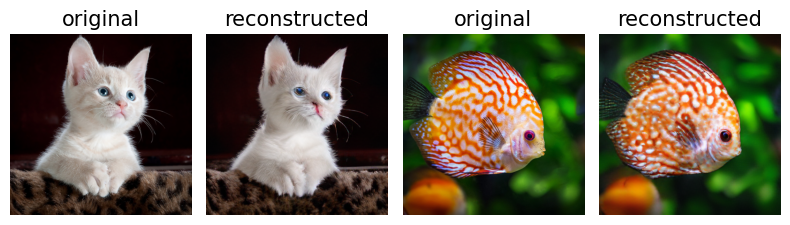

In [8]:
import matplotlib.pyplot as plt

imgs=[image1[0].cpu().permute(1,2,0)*0.5+0.5,    #A
      reconstruct1[0].cpu().permute(1,2,0)*0.5+0.5,
      image2[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"]*2    #B

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    #C
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()
#A Place the two originals and the two reconstructed images in a list
#B Prepare four captions
#C Plot the four images in a 1x4 grid

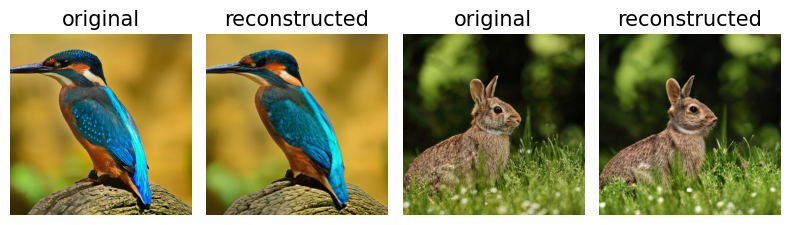

In [9]:
# answer to exercise 11.2
imgs=[image3[0].cpu().permute(1,2,0)*0.5+0.5,    
      reconstruct3[0].cpu().permute(1,2,0)*0.5+0.5,
      image4[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct4[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"]*2    

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
z=model.encoder(image1.to(device))
z=model.quant_conv(z) 
print(f"the shape of the latent representation is {z.shape}")

the shape of the latent representation is torch.Size([1, 256, 24, 24])


We can try another five images as follows:

In [11]:
z_q, _ , indices= model.quantize(z)    #A
int_sequence = indices[2]    #B
print(int_sequence)
#A Quantize the latent vectors by replacing each one with its nearest neighbor in the codebook, producing quantized vectors z_q.
#B Extract the sequence of integer indices (int_sequence), where each integer corresponds to the index of the selected codebook vector for a given patch

tensor([ 873,  862,  873,  862,  862,   63,  110,  455,  590,  481,   29,  813,
         455,  813,  812,  813,  862,  862,   96,  862,  862,   63,   96,   96,
         312,   96,  894,  556,  717,   36,  812,  717,  742,  790,  350,  455,
         946,  937,  154,  772,  455,  813,  979,  110,  812,  813,  868,  717,
         862,  154,  862,  110,  154,  812,  325,  438,  875,  200,  669,   63,
         630,  404,  993,  623,  572,  668,  376,  520,  110,  623,  873,  325,
         523,  312,  623,  110,  937,  812,  623,  771,  585,  577,  119,  172,
         910,  520,  717,  862,  956,   35,   36,  590,  813,  993,  701,  701,
          96,  325,  450,  256,  168,  154,  455,  184,  816,  932,  237,   31,
         849,  479,  343,  575,  628,  185,  534,  261,  325,  862,  937,  873,
         590,  154,  325,  110,  710,  937,  813,  444,   39,  550,  350,  610,
         136,  354,  578,  301,  175,  706,  807,  450,  330,  168,  718,  312,
          96,  993,   63,  813,  154,  7

In [12]:
# answer to exercise 11.3
z2=model.encoder(image2.to(device))
z2=model.quant_conv(z2) 

z2_q, _ , indices2= model.quantize(z2)    #A
int_sequence2 = indices2[2]    #B
print(int_sequence2)

tensor([ 508,  343,  261,  508,  156,  596,  634,  534,  508,  501,  253,  970,
         881,  500,  508,  500,  873,  433,  976,  294,   29,  455,  455,  717,
         110,  154,  556,  941,  909,  542,  156,  601,  869,  856,  187,  911,
         168,  534,  705,  261,  965,  313,  553,  903,  171,  862,  154,  623,
         312, 1019,  556,  156,  156,  460,  503,  642,  992,  966,  192,  222,
         556,  856,  856,  460,  909,  363,  634,  577,  972,  156,  681,  316,
         343,  556,  343,  514,  287,  438,  587,  772,  588,  671,  787,  129,
         764,  255,  990,  156,  593,  634,  164,  590,  639,  542,  156,  884,
         705,  990,  810,  333,    7,  662,  772,  109,   84,  932,  494,  936,
         857,  373,  788,  556,   20,  909,  601,  903,  970,  903,  156,  881,
         250,   44,  972,  325,  237,  438,  941,  217,  260,  400,  656,  598,
         658,  671, 1017,  870,  884,  156,  688,  911, 1007,  432,  577,  363,
         110, 1019,  438,  911,  918,  6

In [13]:
z_q2 = model.quantize.embedding(int_sequence)
z_q2 = z_q2.permute(1,0).view(z_q.shape)    #A
z_post2 = model.post_quant_conv(z_q2)
z_recon2 = model.decoder(z_post2)    #B

In [14]:
# answer to exercise 11.4
z2_q2 = model.quantize.embedding(int_sequence2)
z2_q2 = z2_q2.permute(1,0).view(z_q.shape)    #A
z2_post2 = model.post_quant_conv(z2_q2)
z2_recon2 = model.decoder(z2_post2)    #B

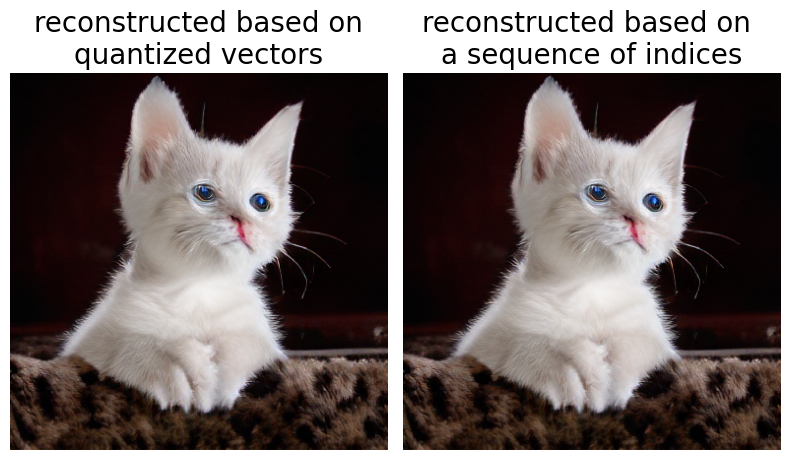

In [15]:
z_post = model.post_quant_conv(z_q)
z_recon = model.decoder(z_post)    #A

imgs=[z_recon[0].cpu().permute(1,2,0)*0.5+0.5,
      z_recon2[0].cpu().permute(1,2,0)*0.5+0.5]    

captions=["reconstructed based on\nquantized vectors",
          "reconstructed based on \na sequence of indices"]

plt.figure(figsize=(8,5),dpi=100)
for i in range(2):    #B
    plt.subplot(1,2,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=20)    
    plt.axis('off')
plt.tight_layout()
plt.show()
#A Reconstruct the cat image using the quantized latent representation, z_q
#B Compare the reconstructed image based on z_q and that based on the sequence of indices 

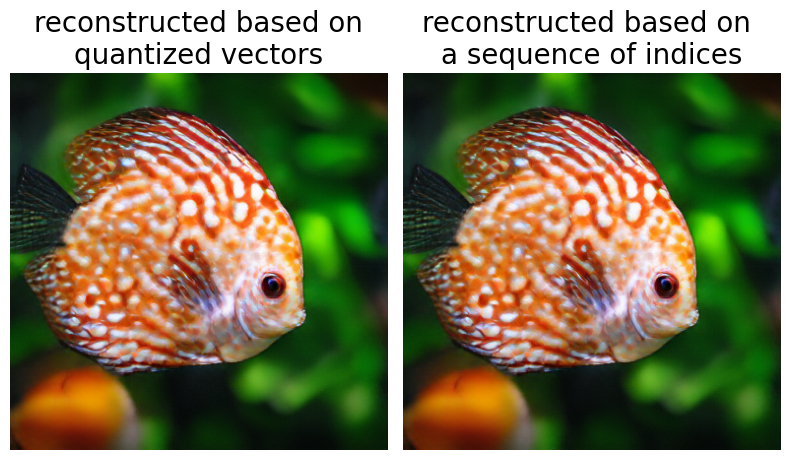

In [16]:
# answer to exercise 11.5
z2_post = model.post_quant_conv(z2_q)
z2_recon = model.decoder(z2_post)    

imgs=[z2_recon[0].cpu().permute(1,2,0)*0.5+0.5,
      z2_recon2[0].cpu().permute(1,2,0)*0.5+0.5]    

captions=["reconstructed based on\nquantized vectors",
          "reconstructed based on \na sequence of indices"]

plt.figure(figsize=(8,5),dpi=100)
for i in range(2):    
    plt.subplot(1,2,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=20)    
    plt.axis('off')
plt.tight_layout()
plt.show()